# Thực hành Buổi 09: Diagnostic Analytics & Anomaly Detection (Isolation Forest)

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Scikit-Learn IsolationForest, Seaborn

**Đầu vào ➔ Đầu ra:** dataset giao dịch sạch của Bài 6 ➔ danh sách quan sát dị biệt (`data/processed/outlier_report.csv`)

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.
> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` trước — buổi này đọc `data/processed/enterprise_transactions_clean.parquet` và `data/raw/customer_churn.csv` do Bài 6 sinh ra.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


# BÀI 9 — DIAGNOSTIC ANALYTICS & ANOMALY DETECTION (ISOLATION FOREST)

Bài 8 mô tả *chuyện gì xảy ra*. Bài 9 lên một bậc thang phân tích: **vì sao nó xảy ra** (diagnostic) và **quan sát nào không giống ai** (anomaly detection).

## 9.0. Nạp dữ liệu

Đọc lại dataset sạch của Bài 6, lọc giao dịch hoàn tất và gắn cột tháng (giống Bài 8):

In [2]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
tx["thang"] = tx["ts"].dt.to_period("M").astype(str)
tx_ht = tx[tx["status"] == "HOAN_TAT"].copy()
print(f"Giao dịch sạch: {len(tx):,} | hoàn tất: {len(tx_ht):,}")

Giao dịch sạch: 59,985 | hoàn tất: 57,882


## 9.1. Chẩn đoán: tháng biến động mạnh nhất do đâu?

Kỹ thuật **phân rã đóng góp (contribution analysis)**: chênh lệch doanh thu giữa hai tháng = tổng chênh lệch của từng ngành hàng / chi nhánh. Nhìn vào phần tử đóng góp lớn nhất là thấy "thủ phạm".

Tháng biến động mạnh nhất: 2025-03 so với 2025-02: +501 triệu đ


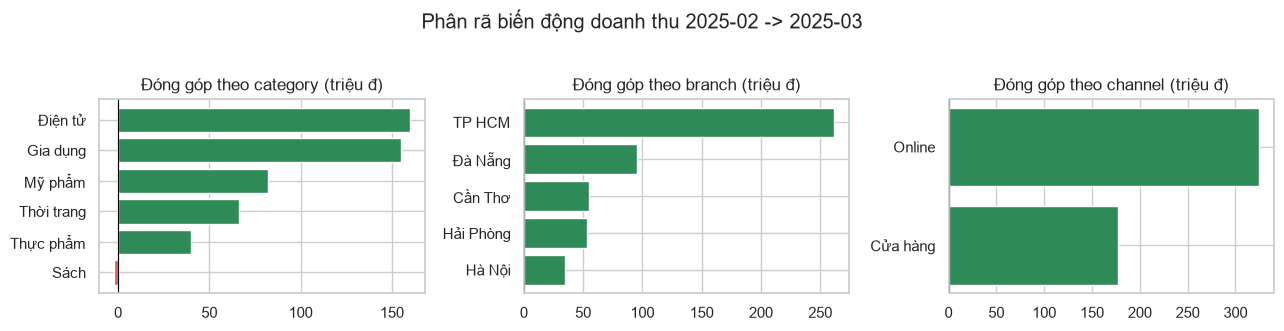

In [3]:
dt_thang = tx_ht.groupby("thang")["amount"].sum()
bien_dong = dt_thang.diff()
# Chỉ xét các tháng đủ dữ liệu (bỏ tháng đầu và tháng cuối cụt)
thang_xet = bien_dong.iloc[2:-1] if len(bien_dong) > 3 else bien_dong.iloc[1:]
thang_muc_tieu = thang_xet.abs().idxmax()
thang_truoc = dt_thang.index[dt_thang.index.get_loc(thang_muc_tieu) - 1]
print(f"Tháng biến động mạnh nhất: {thang_muc_tieu} so với {thang_truoc}: "
      f"{bien_dong[thang_muc_tieu]/1e6:+,.0f} triệu đ")

phan_ra = {}
for chieu in ["category", "branch", "channel"]:
    a = tx_ht[tx_ht["thang"] == thang_truoc].groupby(chieu, observed=True)["amount"].sum()
    b = tx_ht[tx_ht["thang"] == thang_muc_tieu].groupby(chieu, observed=True)["amount"].sum()
    phan_ra[chieu] = (b - a).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (chieu, s) in zip(axes, phan_ra.items()):
    mau = ["indianred" if v < 0 else "seagreen" for v in s.values]
    ax.barh(s.index.astype(str), s.values / 1e6, color=mau)
    ax.set_title(f"Đóng góp theo {chieu} (triệu đ)")
    ax.axvline(0, color="black", lw=0.8)
plt.suptitle(f"Phân rã biến động doanh thu {thang_truoc} -> {thang_muc_tieu}", y=1.03)
plt.tight_layout(); plt.show()

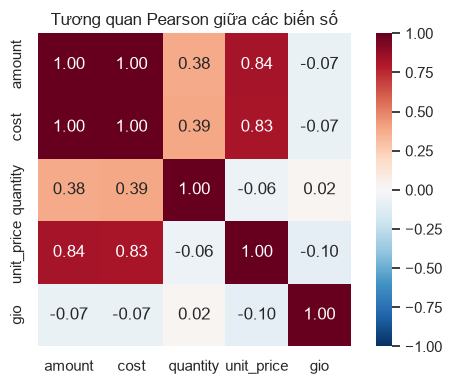

In [4]:
# Ma trận tương quan các biến số — biến nào "kéo" biến nào?
so_lieu = tx_ht[["amount", "cost", "quantity", "unit_price"]].assign(
    gio=tx_ht["ts"].dt.hour)
plt.figure(figsize=(5.5, 4))
sns.heatmap(so_lieu.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True)
plt.title("Tương quan Pearson giữa các biến số")
plt.tight_layout(); plt.show()

## 9.2. Isolation Forest — trực giác và triển khai

**Trực giác:** dựng nhiều cây nhị phân, mỗi nút cắt ngẫu nhiên một biến tại một ngưỡng ngẫu nhiên. Điểm **bất thường nằm lẻ loi** nên chỉ cần **rất ít nhát cắt** là bị cô lập; điểm bình thường nằm giữa đám đông nên cần nhiều nhát cắt. **Độ sâu cô lập trung bình càng nông ➔ càng bất thường.** Ưu điểm: không cần nhãn, không cần giả định phân phối, chạy nhanh trên dữ liệu lớn — khác hẳn Z-Score/IQR ở chỗ nhìn **nhiều chiều cùng lúc** (một giao dịch 3h sáng + ví điện tử + giá trị lớn: từng chiều riêng lẻ chưa chắc dị biệt, tổ hợp lại thì rất dị biệt).

Tham số quan trọng nhất: `contamination` — tỷ lệ dị biệt kỳ vọng (ở đây đặt 2% theo kinh nghiệm nghiệp vụ).

In [5]:
from sklearn.ensemble import IsolationForest

X_if = pd.DataFrame({
    "log_amount": np.log1p(tx_ht["amount"]),
    "log_unit_price": np.log1p(tx_ht["unit_price"]),
    "quantity": tx_ht["quantity"],
    "gio": tx_ht["ts"].dt.hour,
    "thu": tx_ht["ts"].dt.dayofweek,
    "la_online": tx_ht["channel"].eq("Online").astype(int),
    "la_vi_dien_tu": tx_ht["payment_method"].eq("VI_DIEN_TU").astype(int),
}, index=tx_ht.index)

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
tx_ht = tx_ht.copy()
tx_ht["diem_bat_thuong"] = iso.fit_predict(X_if)          # -1 = bất thường
tx_ht["score"] = iso.score_samples(X_if)                  # càng ÂM càng bất thường
n_bt = (tx_ht["diem_bat_thuong"] == -1).sum()
print(f"Gắn cờ {n_bt:,} / {len(tx_ht):,} giao dịch ({n_bt/len(tx_ht):.1%}) là bất thường")

Gắn cờ 1,158 / 57,882 giao dịch (2.0%) là bất thường


## 9.3. Trực quan hóa và chân dung điểm bất thường

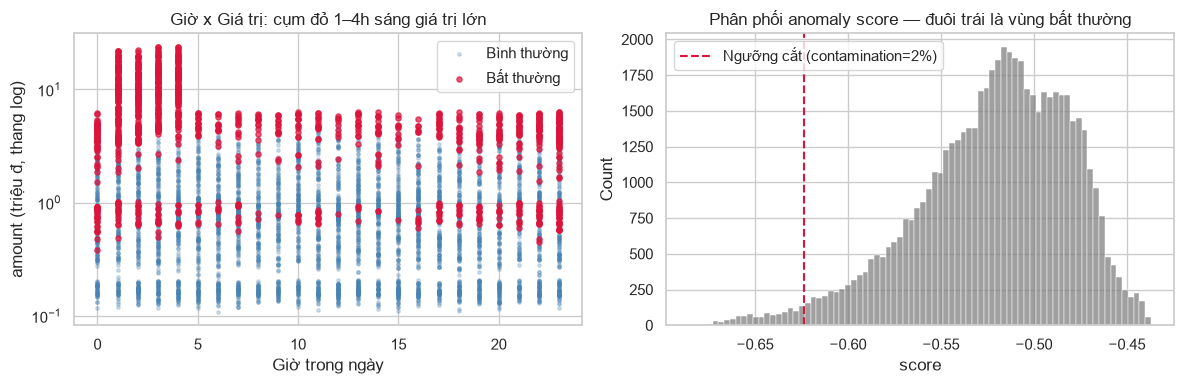

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
binh_thuong = tx_ht[tx_ht["diem_bat_thuong"] == 1].sample(5000, random_state=0)
bat_thuong = tx_ht[tx_ht["diem_bat_thuong"] == -1]

axes[0].scatter(binh_thuong["ts"].dt.hour, binh_thuong["amount"] / 1e6,
                s=6, alpha=0.25, label="Bình thường", color="steelblue")
axes[0].scatter(bat_thuong["ts"].dt.hour, bat_thuong["amount"] / 1e6,
                s=14, alpha=0.7, label="Bất thường", color="crimson")
axes[0].set_yscale("log")
axes[0].set_xlabel("Giờ trong ngày"); axes[0].set_ylabel("amount (triệu đ, thang log)")
axes[0].set_title("Giờ x Giá trị: cụm đỏ 1–4h sáng giá trị lớn")
axes[0].legend()

sns.histplot(tx_ht["score"], bins=80, ax=axes[1], color="gray")
axes[1].axvline(tx_ht.loc[tx_ht["diem_bat_thuong"] == -1, "score"].max(),
                color="crimson", ls="--", label="Ngưỡng cắt (contamination=2%)")
axes[1].set_title("Phân phối anomaly score — đuôi trái là vùng bất thường")
axes[1].legend()
plt.tight_layout(); plt.show()

In [7]:
# Chân dung: nhóm bất thường khác nhóm bình thường ở đâu?
chan_dung = (tx_ht.assign(nhom=np.where(tx_ht["diem_bat_thuong"] == -1,
                                        "Bất thường", "Bình thường"),
                          gio=tx_ht["ts"].dt.hour)
             .groupby("nhom")
             .agg(so_gd=("transaction_id", "size"),
                  amount_tb=("amount", "mean"),
                  gio_tb=("gio", "mean"),
                  ty_le_vi=("payment_method", lambda s: s.eq("VI_DIEN_TU").mean()),
                  ty_le_online=("channel", lambda s: s.eq("Online").mean())))
chan_dung.round(2)

,so_gd,amount_tb,gio_tb,ty_le_vi,ty_le_online
nhom,,,,,
Bình thường,56724,"940,104.74",11.44,0.27,0.45
Bất thường,1158,"6,156,467.19",8.82,0.80,0.54


## 9.4. Đối chiếu với nhãn gian lận cấy sẵn

Trong thực tế **không có nhãn** — Isolation Forest chính là công cụ khoanh vùng để đội điều tra rà soát. Ở đây, vì dữ liệu do ta tự sinh nên có cột `is_fraud` làm "đáp án" để chấm điểm thuật toán:

In [8]:
from sklearn.metrics import precision_score, recall_score

du_doan = (tx_ht["diem_bat_thuong"] == -1).astype(int)
print(pd.crosstab(tx_ht["is_fraud"], du_doan,
                  rownames=["Thực tế (is_fraud)"], colnames=["IF gắn cờ"]))
print(f"\nPrecision: {precision_score(tx_ht['is_fraud'], du_doan):.1%}"
      f"  (trong số bị gắn cờ, bao nhiêu đúng là gian lận)")
print(f"Recall   : {recall_score(tx_ht['is_fraud'], du_doan):.1%}"
      f"  (trong số gian lận thật, bắt được bao nhiêu)")

IF gắn cờ               0    1
Thực tế (is_fraud)            
0                   56419  772
1                     305  386

Precision: 33.3%  (trong số bị gắn cờ, bao nhiêu đúng là gian lận)
Recall   : 55.9%  (trong số gian lận thật, bắt được bao nhiêu)


> Thuật toán **không hề biết nhãn** mà vẫn bắt được hơn một nửa số giao dịch gian lận, trong khi chỉ phải rà soát 2% dữ liệu — vì gian lận, theo định nghĩa, là *hành vi không giống số đông*. Phần bị gắn cờ nhưng không phải gian lận cũng **không vô ích**: đó thường là giao dịch VIP, lỗi hệ thống, hoặc chương trình khuyến mãi bất thường — đều đáng để nghiệp vụ xem xét.

## 9.5. Xuất danh sách quan sát dị biệt (deliverable)

In [9]:
bao_cao_outlier = (bat_thuong
    .assign(gio=bat_thuong["ts"].dt.hour)
    [["transaction_id", "ts", "customer_id", "branch", "channel", "category",
      "quantity", "unit_price", "amount", "payment_method", "gio", "score"]]
    .sort_values("score"))
bao_cao_outlier.to_csv(PROCESSED / "outlier_report.csv", index=False)
print(f"Đã lưu {len(bao_cao_outlier):,} quan sát dị biệt vào "
      f"{PROCESSED / 'outlier_report.csv'}")
print("\nTop 10 giao dịch đáng ngờ nhất (score càng âm càng đáng ngờ):")
bao_cao_outlier.head(10)

Đã lưu 1,158 quan sát dị biệt vào ..\data\processed\outlier_report.csv

Top 10 giao dịch đáng ngờ nhất (score càng âm càng đáng ngờ):


,transaction_id,ts,customer_id,branch,channel,category,quantity,unit_price,amount,payment_method,gio,score
38636,T0038646,2025-07-20 23:42:43,C02584,TP HCM,Online,Điện tử,5.00,"1,251,000.00","6,255,000.00",VI_DIEN_TU,23,-0.69
42600,T0042611,2025-08-10 23:04:21,C00354,Hà Nội,Online,Điện tử,5.00,"1,164,000.00","5,820,000.00",VI_DIEN_TU,23,-0.68
42789,T0042800,2025-08-11 23:39:29,C03027,Hà Nội,Cửa hàng,Điện tử,5.00,"1,256,000.00","6,280,000.00",VI_DIEN_TU,23,-0.68
35934,T0035970,2025-07-07 01:27:08,C02888,Đà Nẵng,Cửa hàng,Điện tử,1.00,"20,861,757.19","20,861,757.00",VI_DIEN_TU,1,-0.68
37293,T0037396,2025-07-14 01:01:31,C02026,Hà Nội,Online,Gia dụng,1.00,"15,784,684.54","15,784,685.00",VI_DIEN_TU,1,-0.68
57232,T0057248,2025-10-26 00:31:28,C00059,Hà Nội,Online,Sách,5.00,"142,000.00","674,500.00",VI_DIEN_TU,0,-0.68
13103,T0013192,2025-03-10 01:17:15,C07506,Đà Nẵng,Online,Gia dụng,1.00,"10,936,214.73","10,936,215.00",VI_DIEN_TU,1,-0.68
10391,T0010460,2025-02-24 01:27:57,C01545,TP HCM,Online,Thời trang,1.00,"11,001,346.33","11,001,346.00",VI_DIEN_TU,1,-0.68
21222,T0021339,2025-04-21 02:16:11,C00315,TP HCM,Online,Điện tử,1.00,"22,471,640.37","22,471,640.00",VI_DIEN_TU,2,-0.67
46640,T0046653,2025-08-31 22:22:48,C07053,TP HCM,Online,Sách,5.00,"128,000.00","640,000.00",VI_DIEN_TU,22,-0.67


---
## TỔNG KẾT PIPELINE 4 BÀI

| Bài | Câu hỏi | Kỹ thuật chính | Sản phẩm |
|:---|:---|:---|:---|
| 6 | Dữ liệu có đáng tin không? | dtypes, MCAR/MAR/MNAR, duplicate, Z-Score/IQR | `enterprise_transactions_clean.parquet` |
| 7 | Mỗi khách hàng là ai? | RFM, biến đổi log, one-hot, StandardScaler | `feature_matrix.parquet` |
| 8 | Chuyện gì đã xảy ra? | KPI, thống kê mô tả, trực quan hóa | Bảng KPI + bộ biểu đồ |
| 9 | Vì sao & điểm nào lạ? | Phân rã đóng góp, Isolation Forest | `outlier_report.csv` |

Ba mức thang phân tích đã đi qua: **Descriptive ➔ Diagnostic**; hai mức còn lại (**Predictive ➔ Prescriptive**) chính là nội dung của các buổi Machine Learning tiếp theo — và Feature Matrix của Bài 7 là cây cầu nối sang đó.

---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (Isolation Forest): Chạy lại Isolation Forest với `contamination` = 0.5%, 1%, 5%. Precision và Recall (so với `is_fraud`) thay đổi theo hướng nào? Giải thích sự đánh đổi (trade-off) này trong 3–4 câu.

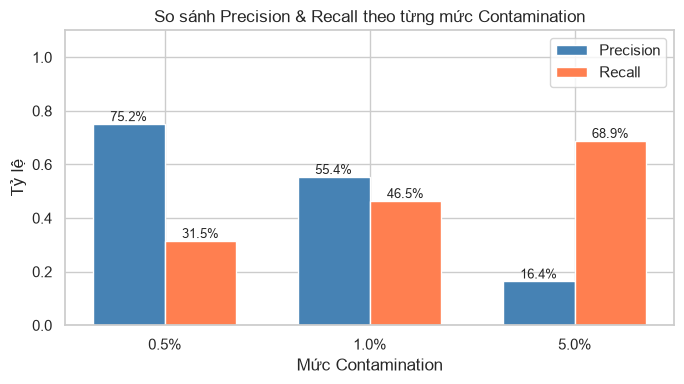

In [14]:
# --- BÀI TẬP 1 (CÓ BIỂU ĐỒ CỘT) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

contamination_values = [0.005, 0.01, 0.05]
ket_qua = []

for contamination in contamination_values:
    iso_test = IsolationForest(
        n_estimators=200, contamination=contamination, random_state=42
    )
    pred = iso_test.fit_predict(X_if)
    du_doan = (pred == -1).astype(int)

    precision = precision_score(
        tx_ht["is_fraud"], du_doan, zero_division=0
    )
    recall = recall_score(
        tx_ht["is_fraud"], du_doan, zero_division=0
    )

    ket_qua.append({
        "Contamination": f"{contamination:.1%}",
        "Precision": precision,
        "Recall": recall,
    })

df_kq = pd.DataFrame(ket_qua)

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
x = np.arange(len(df_kq["Contamination"]))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(
    x - width / 2,
    df_kq["Precision"],
    width,
    label="Precision",
    color="steelblue",
)
plt.bar(
    x + width / 2, df_kq["Recall"], width, label="Recall", color="coral"
)

# Thêm nhãn % lên trên đầu mỗi cột
for i in range(len(x)):
    plt.text(
        x[i] - width / 2,
        df_kq["Precision"][i] + 0.01,
        f"{df_kq['Precision'][i]:.1%}",
        ha="center",
        fontsize=9,
    )
    plt.text(
        x[i] + width / 2,
        df_kq["Recall"][i] + 0.01,
        f"{df_kq['Recall'][i]:.1%}",
        ha="center",
        fontsize=9,
    )

plt.xlabel("Mức Contamination")
plt.ylabel("Tỷ lệ")
plt.title("So sánh Precision & Recall theo từng mức Contamination")
plt.xticks(x, df_kq["Contamination"])
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

#### Bài tập 2 (Diagnostic): Chọn tháng có doanh thu THẤP nhất (bỏ tháng đầu/cuối nếu cụt) và phân rã đóng góp theo `payment_method`. Phương thức thanh toán nào "chịu trách nhiệm" lớn nhất cho mức thấp đó?

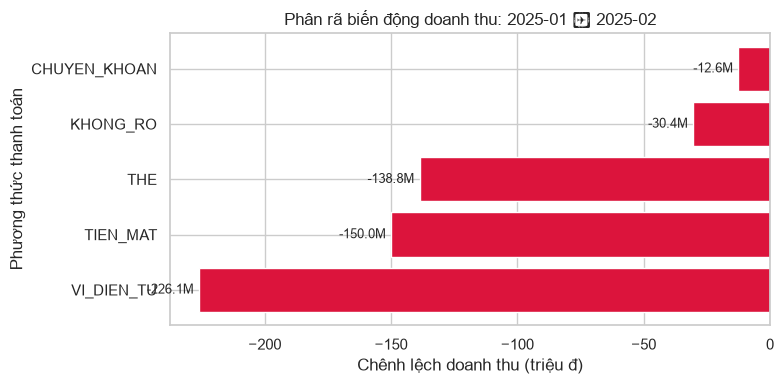


➔ Phương thức thanh toán chịu trách nhiệm lớn nhất cho đợt sụt giảm: VI_DIEN_TU
   Mức sụt giảm: -226,085,490 đ


In [15]:
# --- BÀI TẬP 2 (CÓ BIỂU ĐỒ CỘT) ---
import matplotlib.pyplot as plt
import pandas as pd

# 1. Doanh thu theo tháng
dt_thang = tx_ht.groupby("thang")["amount"].sum()

# 2. Bỏ tháng đầu và tháng cuối
thang_xet = dt_thang.iloc[1:-1] if len(dt_thang) > 2 else dt_thang

# 3. Xác định tháng thấp nhất và tháng trước đó
thang_thap_nhat = thang_xet.idxmin()
vi_tri = dt_thang.index.get_loc(thang_thap_nhat)
thang_truoc = dt_thang.index[vi_tri - 1]

# 4. Tính đóng góp của từng phương thức thanh toán
a = tx_ht[tx_ht["thang"] == thang_truoc].groupby(
    "payment_method", observed=True
)["amount"].sum()
b = tx_ht[tx_ht["thang"] == thang_thap_nhat].groupby(
    "payment_method", observed=True
)["amount"].sum()

phan_ra_payment = (b - a).fillna(0).sort_values()

# 5. Vẽ biểu đồ cột ngang (Barh) với màu sắc phân biệt âm/dương
plt.figure(figsize=(8, 4))
colors = [
    "crimson" if val < 0 else "seagreen" for val in phan_ra_payment.values
]

bars = plt.barh(
    phan_ra_payment.index.astype(str),
    phan_ra_payment.values / 1e6,
    color=colors,
)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")

# Thêm giá trị cụ thể vào đầu mỗi cột
for bar in bars:
    width = bar.get_width()
    offset = -2 if width < 0 else 1
    ha = "right" if width < 0 else "left"
    plt.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.1f}M",
        va="center",
        ha=ha,
        fontsize=9,
    )

plt.xlabel("Chênh lệch doanh thu (triệu đ)")
plt.ylabel("Phương thức thanh toán")
plt.title(f"Phân rã biến động doanh thu: {thang_truoc} ➔ {thang_thap_nhat}")
plt.tight_layout()
plt.show()

# In kết luận
payment_thu_pham = phan_ra_payment.idxmin()
muc_dong_gop = phan_ra_payment.min()
print(
    f"\n➔ Phương thức thanh toán chịu trách nhiệm lớn nhất cho đợt sụt giảm: {payment_thu_pham}"
)
print(f"   Mức sụt giảm: {muc_dong_gop:,.0f} đ")